# Pump Data Exploration

This notebook loads, inspects, validates, and explores the pump sensor dataset before later predictive-maintenance feature engineering.


## Load Dataset

The reusable project loader is used to read the raw pump dataset, with the timestamp column parsed as datetime.


In [191]:
from predictive_maintenance.data.load_data import load_data

df = load_data("../data/raw/pump_data.csv")


## Inspect Dataset Structure

This section reviews the dataset shape, columns, sample rows, and data types.


In [192]:
print(f"Shape: {df.shape}")
print("Columns:")
print(df.columns.tolist())

display(df.head())

df.dtypes


Shape: (720050, 7)
Columns:
['timestamp', 'pump_throughput_m3ph', 'operating_pressure_bar', 'vibration_mm_s', 'bearing_temp_C', 'status', 'pump_number']


,timestamp,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C,status,pump_number
0,2025-04-15 20:14:00.388595,101.948189,9.911733,1.151807,63.317134,RUNNING,1
1,2025-04-15 20:24:00.388595,97.350999,10.015090,1.222389,67.622323,RUNNING,1
2,2025-04-15 20:34:00.388595,98.642862,9.890661,1.284898,67.834281,RUNNING,1
3,2025-04-15 20:44:00.388595,101.125591,10.136244,1.010065,64.876550,RUNNING,1
4,2025-04-15 20:54:00.388595,102.167705,10.048706,0.981551,69.590331,RUNNING,1


timestamp                 datetime64[us]
pump_throughput_m3ph             float64
operating_pressure_bar           float64
vibration_mm_s                   float64
bearing_temp_C                   float64
status                               str
pump_number                        int64
dtype: object

## Data Quality Checks

This section verifies that the dataset is suitable for downstream analysis by checking missing values, duplicate rows, schema expectations, and validation results.


In [193]:
quality_summary = {
    "missing_values": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "timestamp_dtype": str(df["timestamp"].dtype),
    "pump_count": int(df["pump_number"].nunique()),
}

quality_summary


{'missing_values': 0,
 'duplicate_rows': 0,
 'timestamp_dtype': 'datetime64[us]',
 'pump_count': 50}

## Pump Status Distribution

This section analyzes RUNNING versus DOWN observations and checks for class imbalance.


In [194]:
status_counts = df["status"].value_counts()

status_counts

status
RUNNING    671600
DOWN        48450
Name: count, dtype: int64

### Status Percentages


In [195]:
status_percentages = df["status"].value_counts(normalize=True) * 100

status_percentages

status
RUNNING    93.271301
DOWN        6.728699
Name: proportion, dtype: float64

### Status Distribution Visualization


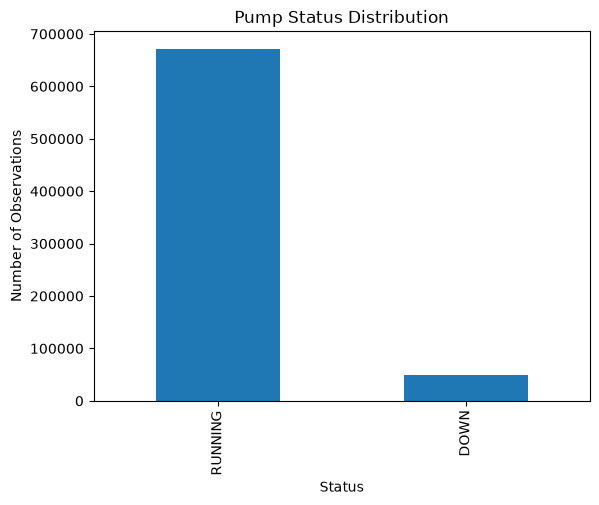

In [196]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")

plt.title("Pump Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Observations")
plt.show()

### Status Summary Table


In [197]:
status_summary = df["status"].value_counts().to_frame(name="count")
status_summary["percentage"] = (
    df["status"].value_counts(normalize=True) * 100
)

status_summary

,count,percentage
status,,
RUNNING,671600,93.271301
DOWN,48450,6.728699


## Initial Observations

The dataset contains 50 pumps, has no missing values or duplicate rows, timestamps are suitable for chronological analysis, and the target is imbalanced with substantially more RUNNING than DOWN observations.

Future model evaluation should consider precision, recall, F1, ROC-AUC, and PR-AUC rather than accuracy alone.


## Identify Distinct Downtime Events

A downtime event begins when a pump transitions from RUNNING to DOWN. Consecutive DOWN rows belong to the same event.


In [198]:
downtime_df = df.copy()
downtime_df = downtime_df.sort_values(["pump_number", "timestamp"])


### Previous Pump Status

The previous status for each pump is needed to detect transitions between operating states.


In [199]:
downtime_df["previous_status"] = downtime_df.groupby("pump_number")["status"].shift(1)


### Detect Downtime Starts

A downtime event starts when the current status is DOWN and the previous status was RUNNING.


In [200]:
downtime_df["downtime_start"] = (
    (downtime_df["status"] == "DOWN")
    & (downtime_df["previous_status"] == "RUNNING")
)


### Extract Distinct Downtime Events


In [201]:
downtime_events = downtime_df[downtime_df["downtime_start"] == True]


In [202]:
downtime_events.head()


,timestamp,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C,status,pump_number,previous_status,downtime_start
1238,2025-04-24 10:34:00.388595,0.0,0.0,0.0,25.500748,DOWN,1,RUNNING,True
2596,2025-05-03 20:54:00.388595,0.0,0.0,0.0,27.639492,DOWN,1,RUNNING,True
4053,2025-05-13 23:44:00.388595,0.0,0.0,0.0,27.888169,DOWN,1,RUNNING,True
5287,2025-05-22 13:24:00.388595,0.0,0.0,0.0,20.697955,DOWN,1,RUNNING,True
6496,2025-05-30 22:54:00.388595,0.0,0.0,0.0,20.702499,DOWN,1,RUNNING,True


### Downtime Event Counts


In [203]:
total_downtime_events = downtime_df["downtime_start"].sum()

total_downtime_events


np.int64(500)

## Downtime Frequency by Pump

This section summarizes the number of distinct downtime events experienced by each pump and checks whether downtime is concentrated in a small number of pumps or distributed relatively evenly across the fleet.


### Downtime Events per Pump

Each row in `downtime_events` represents one distinct RUNNING to DOWN transition, so grouping by `pump_number` and counting rows gives the number of downtime events for each pump.


In [204]:
downtime_events_per_pump = downtime_events.groupby("pump_number").size()

downtime_events_per_pump


pump_number
1     10
2     11
3     10
4     10
5      9
6     10
7      9
8      9
9     10
10     9
11     9
12    10
13     9
14    10
15    11
16    10
17    10
18    11
19    11
20    10
21    10
22     9
23     9
24    10
25    10
26    10
27    10
28    11
29    12
30    10
31    10
32    10
33    11
34    10
35     9
36    10
37    11
38    10
39    10
40    10
41     9
42    10
43    10
44    10
45    10
46    10
47     9
48    11
49    10
50    11
dtype: int64

### Downtime Frequency Summary

These statistics summarize the typical number of downtime events across the 50 pumps.


In [205]:
downtime_frequency_summary = {
    "mean": downtime_events_per_pump.mean(),
    "median": downtime_events_per_pump.median(),
    "minimum": downtime_events_per_pump.min(),
    "maximum": downtime_events_per_pump.max(),
}

downtime_frequency_summary

{'mean': np.float64(10.0),
 'median': np.float64(10.0),
 'minimum': np.int64(9),
 'maximum': np.int64(12)}

### Pumps with Highest and Lowest Downtime Frequency

This identifies whether any individual pumps experience noticeably more or fewer downtime events than the rest of the fleet.


In [206]:
highest_downtime_events = downtime_events_per_pump.max()
lowest_downtime_events = downtime_events_per_pump.min()

highest_lowest_downtime = {
    "highest_downtime_pumps": downtime_events_per_pump[
        downtime_events_per_pump == highest_downtime_events
    ].index.tolist(),

    "highest_downtime_events": highest_downtime_events,

    "lowest_downtime_pumps": downtime_events_per_pump[
        downtime_events_per_pump == lowest_downtime_events
    ].index.tolist(),

    "lowest_downtime_events": lowest_downtime_events,
}

highest_lowest_downtime

{'highest_downtime_pumps': [29],
 'highest_downtime_events': np.int64(12),
 'lowest_downtime_pumps': [5, 7, 8, 10, 11, 13, 22, 23, 35, 41, 47],
 'lowest_downtime_events': np.int64(9)}

### Downtime Frequency Visualization

The chart compares the number of distinct downtime events across all pumps.


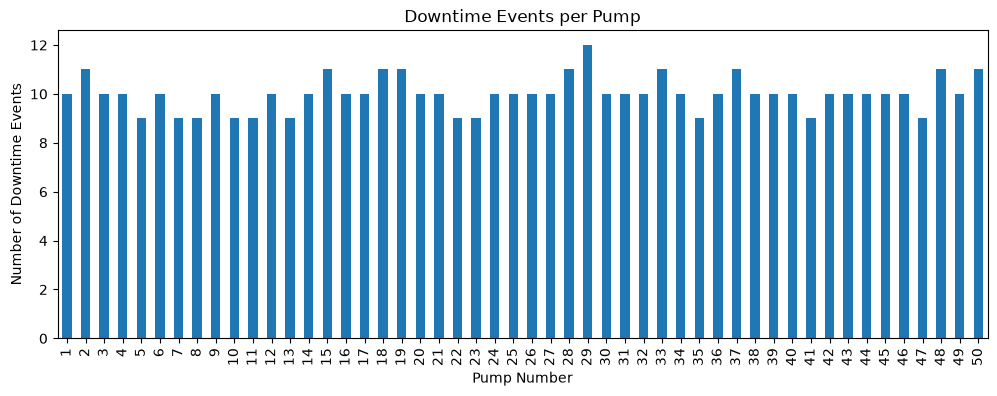

In [207]:
downtime_events_per_pump.plot(kind="bar", figsize=(12, 4))

plt.title("Downtime Events per Pump")
plt.xlabel("Pump Number")
plt.ylabel("Number of Downtime Events")
plt.show()


### Observation

Downtime events appear relatively evenly distributed across the pump fleet, rather than being concentrated in only a small number of pumps. This provides failure examples across many different pump IDs for later predictive-maintenance analysis.


## Downtime Duration

This section measures how long each distinct downtime event lasts by identifying the time between a `RUNNING → DOWN` transition and the next `DOWN → RUNNING` transition for the same pump.

### Assign Downtime Event IDs

Each distinct `RUNNING → DOWN` transition is assigned an event number within its pump.

The cumulative event ID allows consecutive `DOWN` rows belonging to the same outage to be grouped together as one downtime event.

In [208]:
downtime_df["downtime_event_id"] = (
    downtime_df
    .groupby("pump_number")["downtime_start"]
    .cumsum()
)

### Isolate Downtime Observations

Only rows where the pump status is `DOWN` are retained for duration analysis.

This removes normal operating readings and leaves only the observations that belong to downtime periods.

In [209]:
down_rows = downtime_df[
    downtime_df["status"] == "DOWN"
].copy()

### Group Rows into Distinct Downtime Events

Downtime observations are grouped by pump and event ID.

For each event, the earliest timestamp represents the start of the observed downtime period, the latest timestamp represents the final `DOWN` reading, and `down_readings` records how many sensor observations occurred while the pump was down.

In [210]:
downtime_duration = (
    down_rows
    .groupby(["pump_number", "downtime_event_id"])
    .agg(
        downtime_start_time=("timestamp", "min"),
        downtime_end_time=("timestamp", "max"),
        down_readings=("timestamp", "size"),
    )
    .reset_index()
)

### Calculate Downtime Duration

The difference between the first and last `DOWN` timestamps is converted into minutes.

Because sensor readings occur every 10 minutes, an additional 10 minutes is included so that a single `DOWN` observation represents one full sampling interval rather than zero minutes of downtime.

In [211]:
downtime_duration["duration_minutes"] = (
    downtime_duration["downtime_end_time"]
    - downtime_duration["downtime_start_time"]
).dt.total_seconds() / 60

downtime_duration["duration_minutes"] += 10

### Preview Downtime Events


In [212]:
downtime_duration.head()

,pump_number,downtime_event_id,downtime_start_time,downtime_end_time,down_readings,duration_minutes
0,1,1,2025-04-24 10:34:00.388595,2025-04-25 03:34:00.388595,103,1030.0
1,1,2,2025-05-03 20:54:00.388595,2025-05-04 12:04:00.388595,92,920.0
2,1,3,2025-05-13 23:44:00.388595,2025-05-14 14:44:00.388595,91,910.0
3,1,4,2025-05-22 13:24:00.388595,2025-05-23 02:24:00.388595,79,790.0
4,1,5,2025-05-30 22:54:00.388595,2025-05-31 12:34:00.388595,83,830.0


### Downtime Duration Summary

Summary statistics are calculated to describe the typical duration and overall range of downtime events across the pump fleet.

In [213]:
downtime_duration_summary = {
    "mean_minutes": downtime_duration["duration_minutes"].mean(),
    "median_minutes": downtime_duration["duration_minutes"].median(),
    "minimum_minutes": downtime_duration["duration_minutes"].min(),
    "maximum_minutes": downtime_duration["duration_minutes"].max(),
}

downtime_duration_summary

{'mean_minutes': np.float64(969.0),
 'median_minutes': np.float64(960.0),
 'minimum_minutes': np.float64(100.0),
 'maximum_minutes': np.float64(1370.0)}

### Convert Downtime Duration to Hours

Downtime duration is also expressed in hours to make longer outages easier to interpret.

In [214]:
downtime_duration["duration_hours"] = (
    downtime_duration["duration_minutes"] / 60
)

downtime_duration["duration_hours"].describe()

count    500.000000
mean      16.150000
std        2.140274
min        1.666667
25%       14.958333
50%       16.000000
75%       17.500000
max       22.833333
Name: duration_hours, dtype: float64

### Downtime Duration Distribution

The histogram below shows how downtime lengths are distributed across all identified events.

This helps determine whether most outages are relatively short or whether long downtime periods are common.

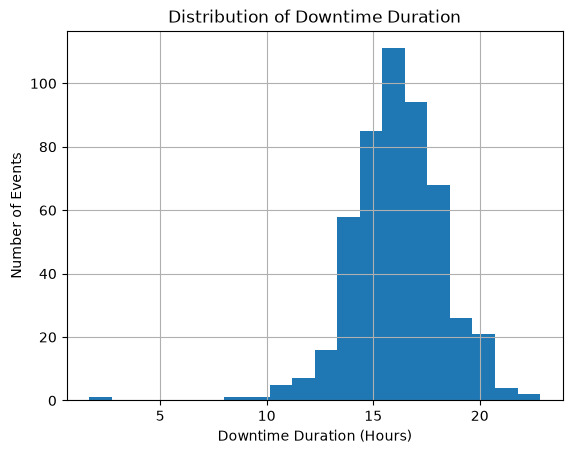

In [215]:
import matplotlib.pyplot as plt

downtime_duration["duration_hours"].hist(bins=20)

plt.title("Distribution of Downtime Duration")
plt.xlabel("Downtime Duration (Hours)")
plt.ylabel("Number of Events")
plt.show()

### Observation

The downtime duration statistics show the typical length and variability of pump outages across the dataset. These results will help characterize failure behavior before we analyze the sensor measurements leading up to each downtime event.

## Sensor Behavior Before Downtime

This section examines pump sensor measurements in the hours leading up to each distinct downtime event.

The goal is to determine whether throughput, operating pressure, vibration, or bearing temperature show meaningful changes before a pump transitions from `RUNNING` to `DOWN`.


### Import Required Library

Pandas is used for time-based calculations, including defining the pre-failure lookback window.


In [216]:
import pandas as pd

### Define Pre-Failure Lookback Window

A six-hour lookback window is used for exploratory analysis.

This does not mean six hours has been selected as the final prediction horizon. It is only being used to inspect how sensor readings behave before downtime.


In [217]:
lookback_hours = 6

### Collect Pre-Failure Sensor Readings

For each distinct downtime event, collect the previous six hours of `RUNNING` observations for the same pump.

The downtime timestamp itself and any later readings are excluded so that only information available before the pump goes down is included.


In [218]:
prefailure_rows = []

for _, event in downtime_events.iterrows():
    pump_number = event["pump_number"]
    failure_time = event["timestamp"]

    start_time = failure_time - pd.Timedelta(hours=lookback_hours)

    event_history = downtime_df[
        (downtime_df["pump_number"] == pump_number)
        & (downtime_df["timestamp"] >= start_time)
        & (downtime_df["timestamp"] < failure_time)
        & (downtime_df["status"] == "RUNNING")
    ].copy()

    event_history["failure_time"] = failure_time

    prefailure_rows.append(event_history)


### Combine Pre-Failure Observations

The pre-failure readings from all downtime events are combined into one DataFrame so sensor behavior can be analyzed across all pumps and events together.


In [219]:
prefailure_df = pd.concat(
    prefailure_rows,
    ignore_index=True
)

### Preview Pre-Failure Data

Inspect the combined pre-failure dataset and confirm that the expected observations were collected.


In [220]:
prefailure_df.head()

,timestamp,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C,status,pump_number,previous_status,downtime_start,downtime_event_id,failure_time
0,2025-04-24 04:34:00.388595,93.710634,9.066112,1.584850,61.496402,RUNNING,1,RUNNING,False,0,2025-04-24 10:34:00.388595
1,2025-04-24 04:44:00.388595,92.870451,8.972221,1.529266,63.093713,RUNNING,1,RUNNING,False,0,2025-04-24 10:34:00.388595
2,2025-04-24 04:54:00.388595,96.717500,8.593754,1.430095,61.815473,RUNNING,1,RUNNING,False,0,2025-04-24 10:34:00.388595
3,2025-04-24 05:04:00.388595,99.627758,8.451042,1.674491,52.308012,RUNNING,1,RUNNING,False,0,2025-04-24 10:34:00.388595
4,2025-04-24 05:14:00.388595,101.931601,7.785967,1.224254,57.520104,RUNNING,1,RUNNING,False,0,2025-04-24 10:34:00.388595


In [221]:
prefailure_df.shape

(18000, 11)

### Calculate Time Before Failure

For each sensor reading, calculate how many hours remained until its associated downtime event.

This allows observations from different pumps and events to be aligned relative to the moment of failure.


In [222]:
prefailure_df["hours_before_failure"] = (
    prefailure_df["failure_time"]
    - prefailure_df["timestamp"]
).dt.total_seconds() / 3600

### Inspect Pre-Failure Sensor Measurements

Calculate summary statistics for the main sensor variables during the six-hour period before downtime.


In [223]:
sensor_columns = [
    "pump_throughput_m3ph",
    "operating_pressure_bar",
    "vibration_mm_s",
    "bearing_temp_C",
]

prefailure_df[sensor_columns].describe()

,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C
count,18000.000000,18000.000000,18000.000000,18000.000000
mean,99.841526,9.529671,1.494681,68.937157
std,3.477365,0.648245,0.447914,6.630323
min,86.584767,7.131883,0.000000,44.469783
25%,97.512638,9.128698,1.188940,64.474663
50%,99.850975,9.565303,1.477465,68.682738
75%,102.230327,9.969997,1.785340,73.158002
max,117.049782,12.047137,3.241878,96.225883


### Group Readings by Time Before Downtime

The six-hour pre-failure period is divided into three time windows:

- 0–1 hour before downtime
- 1–3 hours before downtime
- 3–6 hours before downtime

This allows sensor readings close to failure to be compared with readings further away from failure.


In [224]:
prefailure_df["time_window"] = pd.cut(
    prefailure_df["hours_before_failure"],
    bins=[0, 1, 3, 6],
    labels=[
        "0-1 hours",
        "1-3 hours",
        "3-6 hours",
    ],
    include_lowest=True,
)

### Average Sensor Behavior by Time Window

Calculate the average value of each sensor measurement within each pre-failure time window.

Comparing these averages can reveal whether sensor measurements begin changing as downtime approaches.


In [225]:
sensor_behavior_by_window = (
    prefailure_df
    .groupby("time_window", observed=True)[sensor_columns]
    .mean()
)

sensor_behavior_by_window

,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C
time_window,,,,
0-1 hours,99.635644,9.149276,1.696645,72.129658
1-3 hours,100.006659,9.568575,1.479043,68.692484
3-6 hours,99.800065,9.630534,1.437785,68.036105


### Observation

As downtime approaches, vibration and bearing temperature increase, while operating pressure decreases modestly in the final hour before failure. Pump throughput remains relatively stable across the six-hour window.

These patterns suggest that vibration and bearing temperature may provide useful predictive signal for identifying pumps at elevated risk of entering a `DOWN` state.

## Visualize Pre-Failure Sensor Trends

This section visualizes how key sensor measurements change as downtime approaches.

The plots use the pre-failure time windows created previously to make changes in throughput, operating pressure, vibration, and bearing temperature easier to interpret.

### Prepare Sensor Trend Data

Average sensor values are calculated for each pre-failure time window so the trend toward downtime can be visualized consistently across all events.

In [226]:
sensor_trend_data = (
    prefailure_df
    .groupby("time_window", observed=True)[sensor_columns]
    .mean()
    .reindex([
        "3-6 hours",
        "1-3 hours",
        "0-1 hours",
    ])
)

sensor_trend_data

,pump_throughput_m3ph,operating_pressure_bar,vibration_mm_s,bearing_temp_C
time_window,,,,
3-6 hours,99.800065,9.630534,1.437785,68.036105
1-3 hours,100.006659,9.568575,1.479043,68.692484
0-1 hours,99.635644,9.149276,1.696645,72.129658


### Pump Throughput Trend

This plot shows how average pump throughput changes as downtime approaches.

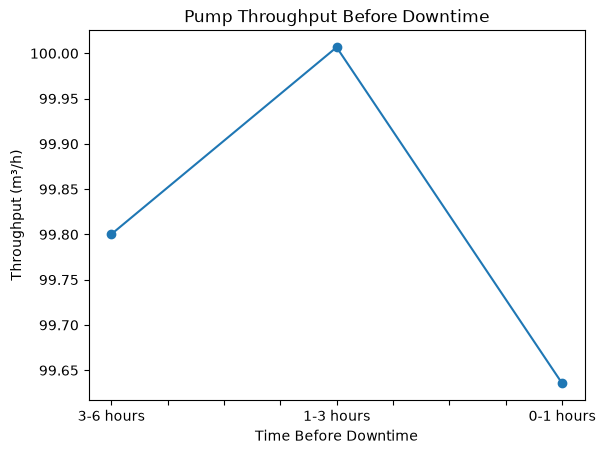

In [227]:
import matplotlib.pyplot as plt

sensor_trend_data["pump_throughput_m3ph"].plot(
    kind="line",
    marker="o"
)

plt.title("Pump Throughput Before Downtime")
plt.xlabel("Time Before Downtime")
plt.ylabel("Throughput (m³/h)")
plt.show()

### Operating Pressure Trend

This plot shows how average operating pressure changes as downtime approaches.

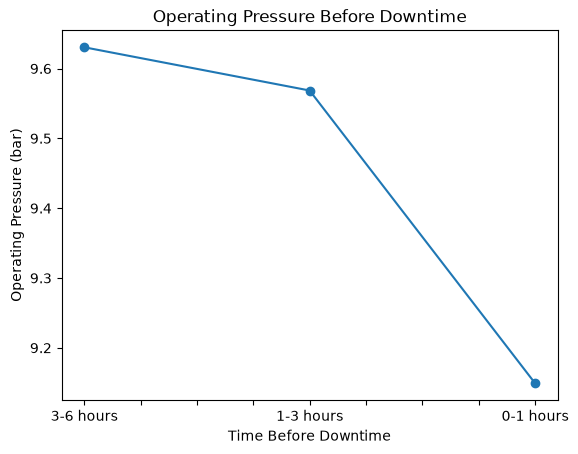

In [228]:
sensor_trend_data["operating_pressure_bar"].plot(
    kind="line",
    marker="o"
)

plt.title("Operating Pressure Before Downtime")
plt.xlabel("Time Before Downtime")
plt.ylabel("Operating Pressure (bar)")
plt.show()

### Vibration Trend

This plot shows how average vibration changes as downtime approaches.

An upward trend closer to downtime may indicate increasing mechanical instability before failure.

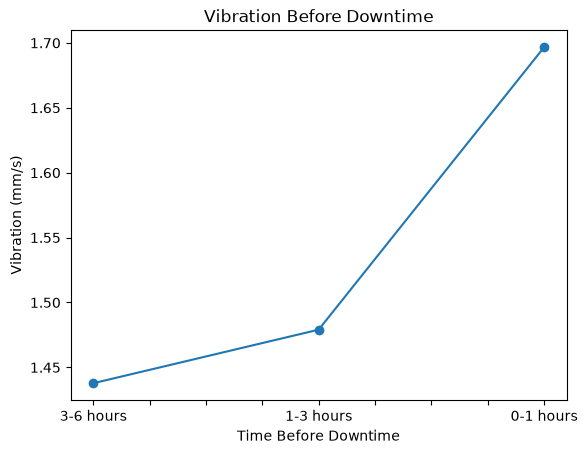

In [229]:
sensor_trend_data["vibration_mm_s"].plot(
    kind="line",
    marker="o"
)

plt.title("Vibration Before Downtime")
plt.xlabel("Time Before Downtime")
plt.ylabel("Vibration (mm/s)")
plt.show()

### Bearing Temperature Trend

This plot shows how average bearing temperature changes as downtime approaches.

An increase closer to downtime may indicate thermal stress or degrading operating conditions before failure.

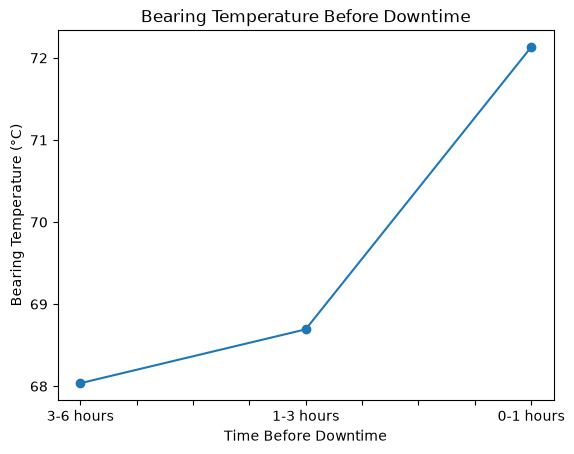

In [230]:
sensor_trend_data["bearing_temp_C"].plot(
    kind="line",
    marker="o"
)

plt.title("Bearing Temperature Before Downtime")
plt.xlabel("Time Before Downtime")
plt.ylabel("Bearing Temperature (°C)")
plt.show()

### Observation

The visualized trends reinforce the earlier numerical analysis.

Vibration and bearing temperature increase as downtime approaches, while operating pressure decreases modestly in the final hour. Pump throughput remains comparatively stable across the six-hour pre-failure period.

These patterns suggest that vibration and bearing temperature may be especially useful features for future failure prediction.

## 11. Compare Candidate Prediction Horizons

This section compares several possible prediction horizons for the future-failure target.

The goal is to determine how many `RUNNING` observations would be labeled as positive if the model were asked to predict whether a pump will enter a `DOWN` state within the next 1, 3, 6, or 12 hours.

A shorter horizon may provide a stronger signal but less advance warning, while a longer horizon provides more warning but may include readings that are less clearly associated with an upcoming failure.


### Define Candidate Prediction Horizons

The candidate prediction windows are 1, 3, 6, and 12 hours before downtime.

These horizons will be compared before selecting the final target definition.


In [231]:
candidate_horizons = [1, 3, 6, 12]


### Prepare Running Observations

Only observations where the pump is currently `RUNNING` are eligible for future-failure labeling.

Rows where the pump is already `DOWN` are excluded because the goal is to predict future downtime rather than identify a failure that has already occurred.


In [232]:
running_df = downtime_df[
    downtime_df["status"] == "RUNNING"
].copy()

running_df.shape


(671600, 10)

### Calculate Time Until the Next Downtime Event

For each `RUNNING` observation, identify the next distinct downtime start for the same pump.

The difference between the current timestamp and the next downtime timestamp represents how much time remains until failure.


In [233]:
event_times_by_pump = {
    pump_number: group["timestamp"].sort_values().to_numpy()
    for pump_number, group in downtime_events.groupby("pump_number")
}


### Assign the Next Failure Time

For every currently running sensor reading, find the earliest downtime event that occurs after that reading for the same pump.

If no later downtime event exists, the next failure time remains missing.


In [234]:
import numpy as np

next_failure_times = []

for _, row in running_df.iterrows():
    pump_number = row["pump_number"]
    current_time = row["timestamp"]

    failure_times = event_times_by_pump[pump_number]

    future_failures = failure_times[
        failure_times > np.datetime64(current_time)
    ]

    if len(future_failures) > 0:
        next_failure_times.append(future_failures[0])
    else:
        next_failure_times.append(pd.NaT)

running_df["next_failure_time"] = next_failure_times


### Calculate Hours Until Failure

The time between each `RUNNING` observation and its next downtime event is converted into hours.

This value will be used to determine whether the observation falls inside each candidate prediction horizon.


In [235]:
running_df["hours_until_failure"] = (
    running_df["next_failure_time"]
    - running_df["timestamp"]
).dt.total_seconds() / 3600


### Preview Future-Failure Timing

Inspect the current timestamp, next failure timestamp, and calculated hours until failure to confirm that the future-failure mapping is working correctly.


In [236]:
running_df[
    [
        "pump_number",
        "timestamp",
        "next_failure_time",
        "hours_until_failure",
    ]
].head(10)


,pump_number,timestamp,next_failure_time,hours_until_failure
0,1,2025-04-15 20:14:00.388595,2025-04-24 10:34:00.388595,206.333333
1,1,2025-04-15 20:24:00.388595,2025-04-24 10:34:00.388595,206.166667
2,1,2025-04-15 20:34:00.388595,2025-04-24 10:34:00.388595,206.000000
3,1,2025-04-15 20:44:00.388595,2025-04-24 10:34:00.388595,205.833333
4,1,2025-04-15 20:54:00.388595,2025-04-24 10:34:00.388595,205.666667
5,1,2025-04-15 21:04:00.388595,2025-04-24 10:34:00.388595,205.500000
6,1,2025-04-15 21:14:00.388595,2025-04-24 10:34:00.388595,205.333333
7,1,2025-04-15 21:24:00.388595,2025-04-24 10:34:00.388595,205.166667
8,1,2025-04-15 21:34:00.388595,2025-04-24 10:34:00.388595,205.000000
9,1,2025-04-15 21:44:00.388595,2025-04-24 10:34:00.388595,204.833333


### Count Positive Samples for Each Horizon

For each candidate horizon, a `RUNNING` observation is considered positive when the next downtime event occurs within that number of hours.

The total number and percentage of positive samples are calculated for each prediction window.


In [237]:
horizon_results = []

for horizon in candidate_horizons:
    positive_mask = (
        running_df["hours_until_failure"].notna()
        & (running_df["hours_until_failure"] > 0)
        & (running_df["hours_until_failure"] <= horizon)
    )

    positive_count = positive_mask.sum()
    total_count = len(running_df)
    positive_percentage = positive_count / total_count * 100

    horizon_results.append(
        {
            "horizon_hours": horizon,
            "positive_samples": positive_count,
            "total_running_samples": total_count,
            "positive_percentage": positive_percentage,
        }
    )


### Candidate Horizon Summary

The table below compares how many training observations would be labeled as future failures under each candidate prediction horizon.


In [238]:
horizon_summary = pd.DataFrame(horizon_results)

horizon_summary


,horizon_hours,positive_samples,total_running_samples,positive_percentage
0,1,3000,671600,0.446694
1,3,9000,671600,1.340083
2,6,18000,671600,2.680167
3,12,36000,671600,5.360334


### Visualize Positive Sample Rate by Horizon

The percentage of positive observations is visualized for each candidate prediction horizon.

This helps compare the tradeoff between advance warning time and target class balance.


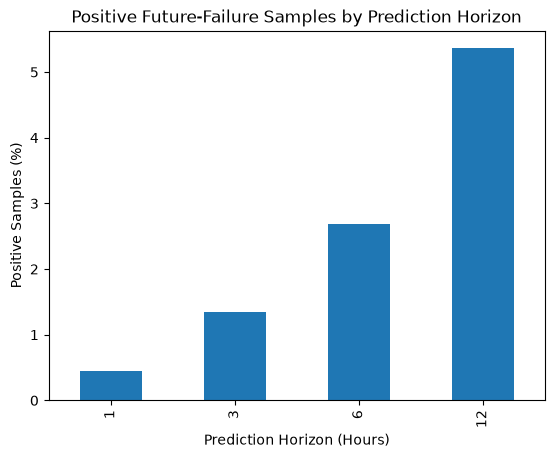

In [239]:
import matplotlib.pyplot as plt

horizon_summary.plot(
    x="horizon_hours",
    y="positive_percentage",
    kind="bar",
    legend=False,
)

plt.title("Positive Future-Failure Samples by Prediction Horizon")
plt.xlabel("Prediction Horizon (Hours)")
plt.ylabel("Positive Samples (%)")
plt.show()


### Interpretation

Shorter prediction horizons are expected to produce fewer positive examples because only readings very close to downtime are labeled as failures.

Longer horizons should produce more positive observations, but they may also include sensor readings taken before strong warning signals are present.

The final prediction horizon should balance:

- Useful advance warning
- Sufficient positive training examples
- Observable pre-failure sensor behavior
- A target definition that remains operationally meaningful
